In [1]:
script = False
cluster = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from efficientnet_pytorch import EfficientNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from astropy.io import fits
from astropy.visualization import make_lupton_rgb

from PIL import Image, ImageOps
from memory_profiler import memory_usage
import random
import os
import gc

if(script):
    from tqdm import tqdm
else: 
    from tqdm.notebook import tqdm

plt.style.use('dark_background')

In [2]:
def seed_everything(seed):
    """
    Seeds basic parameters for reproductibility of results
    Arguments:
        seed {int} -- Number of the seed
    """
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
class ImageDataset(Dataset):
    """Dataset of Images, Data and Labels"""

    def __init__(self, images, data, labels, transform=None):
        """
        Create a PyTorch dataset from an array of images
		and an array of labels
        """
        super().__init__()
        self.images = images
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        #return python image given the index
        image = self.images[idx]
        new_image = image.transpose(1,2,0) 
        new_image = (new_image - new_image.min()) / (new_image.max() - new_image.min())
        new_image = Image.fromarray(np.uint8(255*new_image)).convert("RGB")
        
        #self.plot_image(idx, image, self.transform(new_image))
        
        label = self.labels[idx]
        data_point = self.data.iloc[idx].to_dict()
        
        sample = {'image': self.transform(new_image), 'label': label, 'img': image, 'data': data_point}
        return sample
    
    def normalize_image(self, image):
        image_g = (image[0]-np.mean(image[0]))/ np.std(image[0])
        image_r = (image[1]-np.mean(image[1]))/ np.std(image[1])
        image_i = (image[2]-np.mean(image[2]))/ np.std(image[2])

        image_g = (image_g-np.min(image_g))/ (np.max(image_g) - np.min(image_g))
        image_r = (image_r-np.min(image_r))/ (np.max(image_r) - np.min(image_r))
        image_i = (image_i-np.min(image_i))/ (np.max(image_i) - np.min(image_i))
        return(image_i, image_r, image_g)
    
    def plot_image(self, idx, image, new_image):
        
        plt.figure(figsize=(7,4)) 
        
        plt.subplot(1,2,1)
        plt.title('Original')
        plt.imshow(image[0], aspect='equal')
        plt.axis('off')
        
        plt.subplot(1,2,2)
        plt.title('Transformed')
        img = new_image.permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.axis('off')
        
        plt.show()

    

In [4]:
def make_train_test_datasets(images, data, labels, test_size=0.2, transform=None):
    """
	Make training and testing datasets
	
	Args:
	    images: 3D array of all images
        labels: 1D array of the labels for each image
        test_size: the fraction of the images to use as the test dataset
		transform: the PyTorch transformation to apply to the data
		
	Returns
	    train_dataset: An instance of the ImageDataset Class for training
		test_dataset: An instance of the ImageDataset Class for testing
	"""

    # Shuffle and split data
    y = labels
    train_images, test_images, train_data, test_data, train_labels, test_labels = train_test_split(
        images, data, labels, test_size=test_size, random_state=6)
    
    # Create a PyTorch Dataset
    return (ImageDataset(train_images, train_data, train_labels, transform=transform),
            ImageDataset(test_images, test_data, test_labels, transform=transform))


In [5]:
seed_everything(9)

if(cluster):
    path = '' #OSG
else:
    path = '/Users/jimenagonzalez/research/SkAI_research/SkAI_SLmodeling/Simulations/data/' #local
    
#200
npos = 5000 #5,000
num_workers = 0
num_epochs = 20 #20

images = list(np.load(path + 'images2.npy')) #2
data = pd.read_csv(path + 'data2.csv') #2
print('Total data available: ', len(images), len(data))

images_dataset = images[0:npos]
images_dataset = np.array(images_dataset)
images_dataset = np.stack([images_dataset] * 3, axis=1) #Making them 3 channels
data_dataset = data.iloc[0:npos]

data_tmp = data_dataset.drop(['Ie_source'], axis=1)
#data_tmp = data_dataset # ADLKSFMALDMFLAMSDLFKMASKDMFAKLMDFLKAMSDLFKMASLDKFMALSKDMFLAMDFLKMASDKLFMALKDMF;KASDMFKA
labels_dataset = torch.tensor(data_tmp.values, dtype=torch.float32)

transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            #transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
            ])

print('Shapes of data used: ', images_dataset.shape, data_dataset.shape, labels_dataset.shape)

Total data available:  5000 5000
Shapes of data used:  (5000, 3, 100, 100) (5000, 12) torch.Size([5000, 11])


In [6]:
labels_dataset

tensor([[ 1.8785e-02,  1.2098e-02,  8.4955e-01,  ...,  2.8638e-01,
          2.9621e+00,  4.0061e-01],
        [ 9.8897e-03,  1.5915e-02,  9.5463e-01,  ...,  1.9779e+00,
          2.3647e+00,  6.6434e-01],
        [-1.0392e-02,  1.4128e-02,  7.5789e-01,  ...,  4.7735e+00,
          4.5593e+00,  4.4920e-01],
        ...,
        [-1.9858e-03, -1.6755e-02,  9.6770e-01,  ...,  2.2887e+00,
          2.9233e+00,  9.5231e-01],
        [-8.7412e-03, -5.7250e-03,  9.8635e-01,  ...,  3.9656e+00,
          3.2603e+00,  5.9605e-01],
        [-5.1473e-03, -1.4968e-04,  7.5163e-01,  ...,  4.4085e+00,
          2.2773e+00,  4.4952e-01]])

In [7]:
data_dataset.head()

,x0_mass,y0_mass,q_mass,phi_mass,Rein_mass,x0_source,y0_source,q_source,phi_source,n_source,Re_source,Ie_source
0,0.018785,0.012098,0.849554,2.456778,1.211616,-0.129496,-0.134920,0.913855,0.286377,2.962133,0.400610,28.130245
1,0.009890,0.015915,0.954625,5.834405,1.642769,-0.203703,0.006756,0.976492,1.977943,2.364676,0.664335,28.429363
2,-0.010392,0.014128,0.757885,3.016457,0.003942,0.149515,0.062835,0.904876,4.773533,4.559264,0.449201,17.913481
3,-0.010332,-0.023336,0.666112,4.804803,0.424144,0.165403,-0.073910,0.712874,3.759446,1.483343,0.395260,30.489660
4,-0.008710,-0.002782,0.752106,0.743744,1.146438,-0.335925,-0.152152,0.684645,0.232648,1.772844,0.730516,30.705532


In [8]:
train_dataset, other_dataset = make_train_test_datasets(images_dataset, data_dataset, labels_dataset, test_size=0.2, transform=transform)

#Standardizing the parameters
scaler_y = StandardScaler()
train_dataset.labels = torch.tensor(scaler_y.fit_transform(train_dataset.labels.numpy()), dtype=torch.float32)
other_dataset.labels = torch.tensor(scaler_y.transform(other_dataset.labels.numpy()), dtype=torch.float32)

valid_dataset, test_dataset = make_train_test_datasets(other_dataset.images, other_dataset.data, other_dataset.labels, test_size=0.5, transform=transform)

print(f'Train: {len(train_dataset)}, Valid: {len(valid_dataset)}, Test: {len(test_dataset)}')

Train: 4000, Valid: 500, Test: 500


In [9]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=20, num_workers=num_workers, shuffle=True)
valid_loader = torch.utils.data.DataLoader(dataset=valid_dataset, batch_size=20, num_workers=num_workers, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=20, num_workers=num_workers, shuffle=False)

torch.save(test_loader.dataset, 'test_dataset.pth')

In [10]:
class EfficientNetClass(nn.Module):
    
    def __init__(self, n_classes):
        
        super(EfficientNetClass, self).__init__()
        
        if(not cluster):
            self.model = EfficientNet.from_pretrained('efficientnet-b0',  num_classes=n_classes)
            #torch.save(self.model.state_dict(), 'initial_model.pt')
            torch.save(self.model.state_dict(), 'initial_model.pt')
        else:
            self.model = EfficientNet.from_name('efficientnet-b0',  num_classes=n_classes)
            #self.model.load_state_dict(torch.load('initial_model.pt'))
            slef.model.load_state_dict(torch.load('initial_model.pt', weights_only=True))
        
    def forward(self, x):

        x = self.model(x)

        return x

    def train_one_epoch(self, train_loader, criterion, optimizer, device):
        # keep track of training loss
        epoch_loss = 0.0
        epoch_accuracy = 0.0

        ###################
        # train the model #
        ###################

        self.model.train()

        for i, sample in enumerate(tqdm(train_loader)):

            data, target, sample_img, sample_data = sample['image'], sample['label'] , sample['img'], sample['data']
            
            # move tensors to GPU if CUDA is available
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()

            # clear the gradients of all optimized variables
            optimizer.zero_grad()
            # forward pass: compute predicted outputs by passing inputs to the model
            output = self.forward(data)
            
            # calculate the batch loss
            loss = criterion(output, target)
            # backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()
            
            # Calculate Accuracy
            accuracy = loss # Not needed AKDMFMAKDFMAKFGOIAJEROFMAOIMGOIAJMROGKMAOFMGAOFDLGMAKLFMGK
            
            # update training loss and accuracy
            epoch_loss += loss
            epoch_accuracy += accuracy

            optimizer.step()

        return epoch_loss / len(train_loader), epoch_accuracy / len(train_loader)

    def validate_one_epoch(self, valid_loader, criterion, device):
        # keep track of validation loss
        valid_loss = 0.0
        valid_accuracy = 0.0

        ######################
        # validate the model #
        ######################
        self.model.eval()
        for i, sample in enumerate(tqdm(valid_loader)):
            data, target, sample_img, sample_data = sample['image'], sample['label'] , sample['img'], sample['data']
            
            # move tensors to GPU if CUDA is available
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()

            with torch.no_grad():
                # forward pass: compute predicted outputs by passing inputs to the model
                output = self.model(data)
                # calculate the batch loss
                loss = criterion(output, target)
                # Calculate Accuracy
                accuracy = loss # TO UPDATE ADMFKAMDKFMAKDMFKAJDKGJNAOIERJGOIMRGOIJROITJIOJRGIOSJIFGJMSOIRGJISRJI
                # update average validation loss and accuracy
                valid_loss += loss
                valid_accuracy += accuracy
        
        return valid_loss / len(valid_loader), valid_accuracy / len(valid_loader)

In [11]:
model = EfficientNetClass(n_classes=len(data_tmp.columns))

criterion = torch.nn.HuberLoss() #nn.CrossEntropyLoss() #nn.CrossEntropyLoss() #nn.BCELoss(), torch.nn.MSELoss(), HuberLoss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

learning_rate = 0.00007 #0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

Loaded pretrained weights for efficientnet-b0
cpu


In [12]:
def fit_tpu(model, name_model, epochs, device, criterion, optimizer, train_loader, valid_loader=None):
    
    best_val_loss = float('inf') # track of best loss
    model_data = pd.DataFrame()

    # keeping track of losses as it happen
    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    for epoch in range(1, epochs + 1):
        gc.collect()
        
        print(f"{'=' * 100}")
        print(f"EPOCH {epoch} - TRAINING...")
        train_loss, train_acc = model.train_one_epoch(train_loader, criterion, optimizer, device)
        print(f"\n\t[TRAIN] EPOCH {epoch} - LOSS: {train_loss}, ACCURACY: {train_acc}\n")
        train_losses.append(train_loss.cpu().data.numpy())
        train_accs.append(train_acc.cpu().data.numpy())
        gc.collect()

        # moves towards valid_loader
        print("start valid_loader")

        if valid_loader is not None:
            gc.collect()
            print(f"EPOCH {epoch} - VALIDATING...")
            valid_loss, valid_acc = model.validate_one_epoch(valid_loader, criterion, device)
            print(f"\t[VALID] LOSS: {valid_loss}, ACCURACY: {valid_acc}\n")
            valid_losses.append(valid_loss.cpu().data.numpy())
            valid_accs.append(valid_acc.cpu().data.numpy())
            gc.collect()
            
            if(valid_loss.cpu().data.numpy() < best_val_loss):
                setattr(model, 'loss_train', train_losses)
                setattr(model, 'loss_valid', valid_losses)
                setattr(model, 'train_acc', train_accs)
                setattr(model, 'validation_acc', valid_accs)
                #torch.save(model, name_model)
                torch.save(model.state_dict(), name_model)
                best_val_loss = valid_loss.cpu().data.numpy()
                
    model_data['train_losses'] = train_losses
    model_data['valid_losses'] = valid_losses
    model_data['train_accs'] = train_accs
    model_data['valid_accs'] = valid_accs
    model_data.to_csv('Complete_model.csv', index=False)

In [13]:
def plot_performance(cnn):
    loss_train = [x.item() for x in cnn.loss_train]
    loss_valid = [x.item() for x in cnn.loss_valid]
    train_acc = [x.item() for x in cnn.train_acc]
    valid_acc = [x.item() for x in cnn.validation_acc]
    
    x = np.linspace(1,len(cnn.loss_train),len(cnn.loss_train))
    fig, (ax1, ax2) = plt.subplots(figsize=(16, 7), ncols=2)
    
    ax1.set_title('Losses')
    ax1.set_xlabel('Epoch')
    ax1.scatter(x, loss_train, color = 'skyblue', alpha = 0.8, label = 'Training loss')
    ax1.scatter(x, loss_valid, color = 'limegreen', alpha = 0.8,  label = 'Validation loss')
    ax1.legend()
    
    ax2.set_title('Performance. Max: {:.4f}%'.format(100*cnn.validation_acc[-1].item()))
    ax2.set_xlabel('Epoch')
    ax2.scatter(x, train_acc, color = 'skyblue', alpha = 0.8,  label = 'Training Accuracy')
    ax2.scatter(x, valid_acc, color = 'limegreen', alpha = 0.8,  label = 'Validation Accuracy')
    ax2.legend()
    
    if(script):
        plt.savefig('Performance.png', bbox_inches='tight')
        plt.close()
    else: 
        plt.show(block=True)

In [14]:
name_model = 'model_tmp2.pt' #other, model
#                          model, name_model, epochs, device, criterion, optimizer, train_loader, valid_loader=None
mem_usage = memory_usage(( fit_tpu, (model, name_model, num_epochs, device, criterion, optimizer, train_loader, valid_loader)))



EPOCH 1 - TRAINING...


  0%|          | 0/200 [00:00<?, ?it/s]


	[TRAIN] EPOCH 1 - LOSS: 0.358717679977417, ACCURACY: 0.358717679977417

start valid_loader
EPOCH 1 - VALIDATING...


  0%|          | 0/25 [00:00<?, ?it/s]

	[VALID] LOSS: 0.4515717327594757, ACCURACY: 0.4515717327594757

EPOCH 2 - TRAINING...


...

	[VALID] LOSS: 0.245153546333313, ACCURACY: 0.245153546333313

EPOCH 20 - TRAINING...


  0%|          | 0/200 [00:00<?, ?it/s]


	[TRAIN] EPOCH 20 - LOSS: 0.12200607359409332, ACCURACY: 0.12200607359409332

start valid_loader
EPOCH 20 - VALIDATING...


  0%|          | 0/25 [00:00<?, ?it/s]

	[VALID] LOSS: 0.23975013196468353, ACCURACY: 0.23975013196468353



In [15]:
print('Maximum memory usage: %s' % max(mem_usage))

Maximum memory usage: 4614.125


In [16]:
name = 'model_tmp2.pt'#'model.pt'#'other.pt' 
model.load_state_dict(torch.load(name, weights_only=True))

#dataset = torch.load('test_dataset.pth', weights_only=False) # TO KEEP
#test_loader = DataLoader(dataset, batch_size=test_loader.batch_size, shuffle=False, num_workers=0) # TO KEEP

print('Lowest validation loss (Mean Squared Error): {:.2f}'.format(100*model.loss_valid[-1].item()))

Lowest validation loss (Mean Squared Error): 23.98


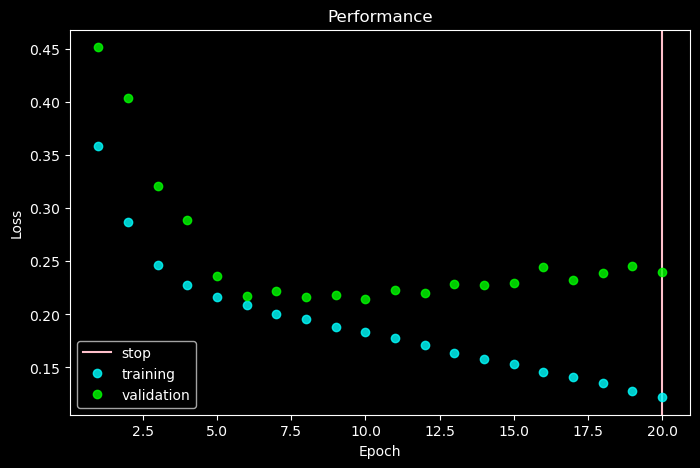

In [17]:
# Plotting complete training
data_model = pd.read_csv('Complete_model.csv')

plt.figure(figsize=(8,5))
plt.xlabel('Epoch')
plt.ylabel('Loss')
x = np.linspace(1, len(data_model), len(data_model))
plt.title('Performance')
plt.axvline(x = len(model.loss_train), label='stop', color='#FFC0CB')
plt.plot(x, data_model['train_losses'].values, 'o', label='training', color='#00FFFF', alpha=0.8)
plt.plot(x, data_model['valid_losses'].values, 'o', label='validation', color='#00FF00', alpha=0.8)
plt.legend()

if(script):
    plt.savefig('Performance.png', bbox_inches='tight')
    plt.close()
else: 
    plt.show(block=True)



In [18]:
def plot_image(image, new_image):
    #image: original, new_image: transformed image (seen by ML)
    
    plt.figure(figsize=(7,4)) 
        
    plt.subplot(1,2,1)
    plt.title('Original')
    plt.imshow(image[0], aspect='equal')
    plt.axis('off')
        
    plt.subplot(1,2,2)
    plt.title('Transformed')
    img = new_image.permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.axis('off')
        
    plt.show()
    plt.close()

def testing_analysis(test_loader):
    predicted_data, true_data = pd.DataFrame(), pd.DataFrame()
    for i, sample in enumerate(tqdm(test_loader)):
        data, target, sample_img, sample_data = sample['image'], sample['label'] , sample['img'], sample['data']
        data_df = pd.DataFrame({k: v.detach().cpu().numpy() for k, v in sample_data.items()})
        #for j in range(len(data)):
        #    print(data_df.iloc[j]['Rein_mass'])
        #    plot_image(sample_img[j], data[j])
            
        # move tensors to GPU if CUDA is available
        if device.type == "cuda":
            data, target = data.cuda(), target.cuda()
        
        output = model.forward(data)
        output = pd.DataFrame(output.detach().cpu().numpy())
        
        predicted_data = pd.concat([predicted_data, output])
        true_data = pd.concat([true_data, pd.DataFrame(target.cpu().numpy())])
        
    return(predicted_data, true_data)

In [19]:
test_dataset = test_loader.dataset
test_images, test_data = test_dataset.images, test_dataset.data
test_data = test_data.reset_index(drop=True)

predicted_data, true_data = testing_analysis(test_loader)

true_data = scaler_y.inverse_transform(true_data) #NEW LINE ASDFASDFASDFASDFASDFASDFASDFADSF
true_data = pd.DataFrame(true_data)
predicted_data = scaler_y.inverse_transform(predicted_data) #NEW LINE ASDFASDFASDFASDFASDFASDFASDFADSF
predicted_data = pd.DataFrame(predicted_data)

  0%|          | 0/25 [00:00<?, ?it/s]

In [20]:
names = data_tmp.columns
#['x0_mass', 'y0_mass', 'q_mass', 'phi_mass', 'Rein_mass', 'x0_source', 'y0_source', 'q_source', 'phi_source', 'n_source', 'Re_source', 'Ie_source']
column_mapping = {old_column: new_column for old_column, new_column in enumerate(names)}
predicted_data.rename(columns=column_mapping, inplace=True)
true_data.rename(columns=column_mapping, inplace=True)

In [21]:
true_data.head()

,x0_mass,y0_mass,q_mass,phi_mass,Rein_mass,x0_source,y0_source,q_source,phi_source,n_source,Re_source
0,0.020059,0.014974,0.593367,3.512436,0.766789,-0.221213,0.001853,0.848885,2.054191,1.844849,1.420824
1,-0.006571,0.011804,0.838793,2.986480,0.665076,-0.148314,0.086454,0.959032,5.917250,1.511311,0.690601
2,-0.007540,-0.007323,0.882920,1.679977,1.318289,-0.058649,0.169468,0.830778,1.829237,3.957485,0.758569
3,-0.010926,0.007146,0.818001,0.408941,0.977186,-0.031058,-0.051191,0.934072,1.006682,1.508243,0.655715
4,-0.002722,-0.005643,0.863434,0.860919,0.897202,-0.184845,-0.001708,0.496971,2.648631,2.265021,1.561556


In [22]:
predicted_data.head()

,x0_mass,y0_mass,q_mass,phi_mass,Rein_mass,x0_source,y0_source,q_source,phi_source,n_source,Re_source
0,-0.002654,0.000658,0.710449,1.307364,0.808858,-0.255866,-0.018862,0.843731,3.921270,1.982903,1.419587
1,0.001439,0.000408,0.927516,2.424056,0.625032,-0.172850,0.109021,0.950966,3.338533,1.433216,0.682342
2,0.001860,0.004141,0.905819,3.371567,1.261515,-0.062029,0.183505,0.899266,2.909776,3.346897,0.678962
3,0.001180,0.000302,0.913553,2.834661,0.963965,-0.035764,-0.017576,0.943964,2.892609,1.493963,0.642122
4,0.001200,-0.002714,0.878094,3.606102,0.973044,-0.153020,-0.002827,0.521776,5.046977,2.378643,1.398960


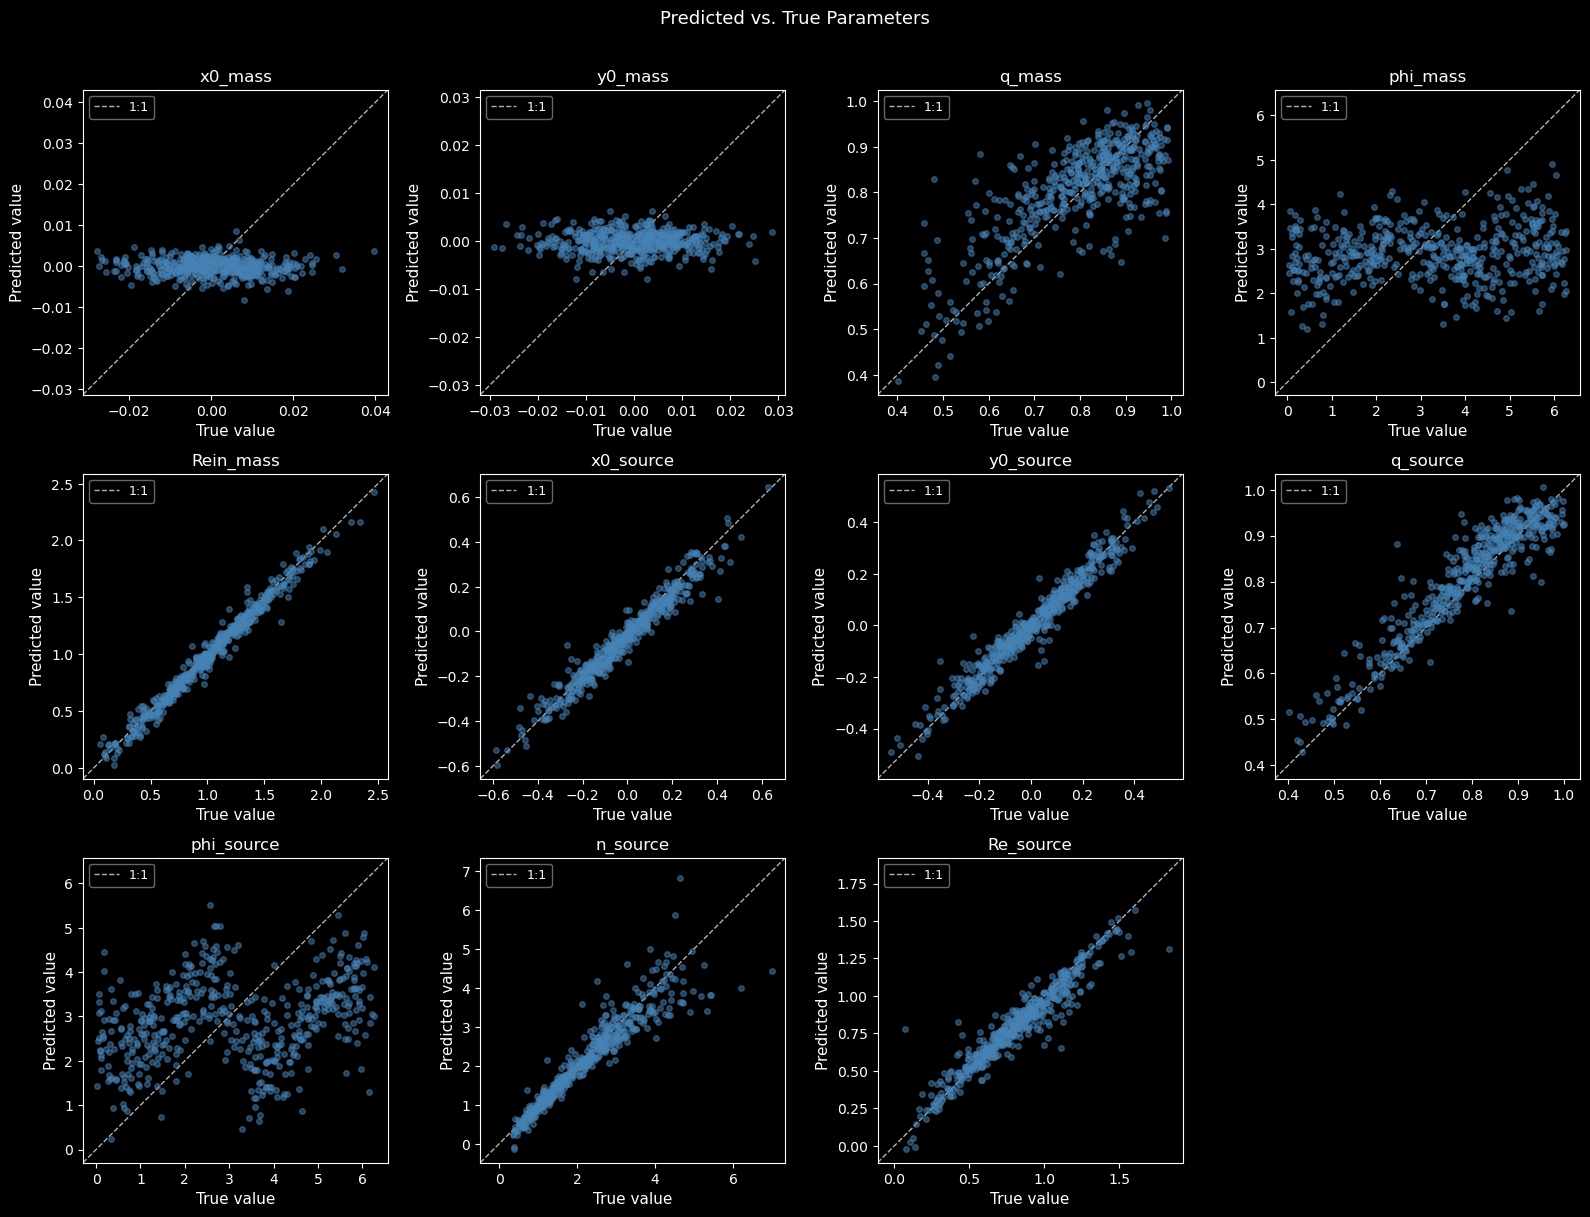

In [23]:
import math

n_cols = 4
n_rows = math.ceil(len(names) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, names)):
    x = np.linspace(min(true_data[name]), max(true_data[name]), 1000)

    # 1:1 reference line
    all_vals = np.concatenate([true_data[name], predicted_data[name]])
    lims = [all_vals.min(), all_vals.max()]
    margin = (lims[1] - lims[0]) * 0.05
    lims = [lims[0] - margin, lims[1] + margin]

    ax.plot(lims, lims, 'w--', linewidth=1, alpha=0.7, label='1:1')
    ax.plot(true_data[name], predicted_data[name], 'o', markersize=4, color='steelblue', alpha=0.5)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('True value', fontsize=11)
    ax.set_ylabel('Predicted value', fontsize=11)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=9, framealpha=0.5)

# Hide unused axes
for ax in axes[len(names):]:
    ax.set_visible(False)

plt.suptitle('Predicted vs. True Parameters', fontsize=13, y=1.01)
plt.tight_layout()

if script:
    plt.savefig('True_Predic_all.png', bbox_inches='tight')
    plt.close()
else:
    plt.show()

In [24]:
data_dataset

,x0_mass,y0_mass,q_mass,phi_mass,Rein_mass,x0_source,y0_source,q_source,phi_source,n_source,Re_source,Ie_source
0,0.018785,0.012098,0.849554,2.456778,1.211616,-0.129496,-0.134920,0.913855,0.286377,2.962133,0.400610,28.130245
1,0.009890,0.015915,0.954625,5.834405,1.642769,-0.203703,0.006756,0.976492,1.977943,2.364676,0.664335,28.429363
2,-0.010392,0.014128,0.757885,3.016457,0.003942,0.149515,0.062835,0.904876,4.773533,4.559264,0.449201,17.913481
3,-0.010332,-0.023336,0.666112,4.804803,0.424144,0.165403,-0.073910,0.712874,3.759446,1.483343,0.395260,30.489660
4,-0.008710,-0.002782,0.752106,0.743744,1.146438,-0.335925,-0.152152,0.684645,0.232648,1.772844,0.730516,30.705532
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.011498,0.018464,0.808299,0.149546,0.880127,-0.020830,0.115035,0.986836,1.673485,2.409339,1.544074,12.170402
4996,0.001074,0.013010,0.964015,3.530316,0.726106,0.326864,-0.304478,0.962962,2.940792,1.837355,1.095310,47.358566
4997,-0.001986,-0.016755,0.967704,4.091096,1.199337,0.051434,-0.003325,0.525216,2.288748,2.923254,0.952312,24.785601
4998,-0.008741,-0.005725,0.986354,3.496890,1.448398,-0.168894,-0.491028,0.954463,3.965621,3.260251,0.596050,15.156746
